# Online RL Thesis — Sprint 0 · Pre-flight

**目的**：进 §2 sensor envelope 之前，先解决两件**会污染 §2 归因**的事：

| Stage | 任务 | 不解决会怎样 |
|---|---|---|
| **P1** | 标定 `single_u15_upstream_tgt15` 的训练预算 | 600k 是 A0 在 cross_u10 推出的；u15_upstream 更难，可能 600k 不够。如果 §2 u15 列因预算不够全员卡 0，无法归因 |
| **P2** | smoke test `--use-asymmetric-critic` 纯 online 路径 | 仓库里 AsymCritic 与 RLPD 一同开发，纯 online 路径未必跑得通。在 §3 fire 12 个正式 run 之前必须确认 |

**对应计划**：[`docs/online_rl_thesis_plan.md`](../docs/online_rl_thesis_plan.md) §5。

**预算**：2 个 run（P1 ≈ 2.5h × 1，P2 ≈ 8min × 1）≈ 1 个 Colab session。


## 0. 环境检查

确认 L4 GPU + CUDA torch 可用。


In [ ]:
!nvidia-smi


Sun Apr 26 10:23:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   44C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count:   {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Device name:    {torch.cuda.get_device_name(0)}")


PyTorch:        2.10.0+cu128
CUDA available: True
Device count:   1
Device name:    NVIDIA L4


## 1. 挂载 Google Drive 并切到项目目录


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
%cd drive/"MyDrive"/"Colab Notebooks"/"new_offRL"/"rl_v2_5"
!pwd


/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5
/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5


## 2. P1 — u15_upstream 训练预算标定

**Setup**：

| 项 | 值 |
|---|---|
| sensor | `s1_k4`（三个 layout 中预期最强，最不可能因 sensor 限制学不动） |
| difficulty | `single_u15_upstream_tgt15` |
| seed | `46` |
| total_steps | `1_000_000`（比 600k 富裕，看 plateau 是否在 600k 后） |
| algo | vanilla SAC，no LayerNorm / no asym / UTD=1 |
| num_envs | `12`（Sprint 0 P0b 实测：12 比 6 快 1.45×；详见 plan §10.2） |

**FLOW_PATH 已自动从 `BENCHMARK_KEY` 推出**（通过 `resolve_benchmark_protocol`），杜绝训练/评估流场不一致。

**STAGE_DIR 加 `_v2_flowfix` 后缀**：旧路径 `preflight/p1_budget_calibration/...` 训练用了 U=1.0 wake，已被 plan §10.0 / §10.3 记为 INVALID。新路径绕开 `run_protocol_stage_common.sh` 的 `[skip] ${RUN_DIR}` 重入逻辑（仅以 `final_eval.json` 是否存在为依据），同时保留旧目录做历史溯源。

**实时日志**：本 cell 通过 `run_streaming` + `PYTHONUNBUFFERED=1` 强制子进程行缓冲，训练日志会随 step 滚动出现在 cell 输出中，不会等到结束才一次性 dump。

**判据**（看 `eval_log.csv` 曲线 plateau 的位置）：

| 观察 | §2 u15 列预算 |
|---|---|
| 600k 之前已 plateau | 用 600k |
| 600k-800k 之间 plateau | 用 800k |
| 800k-1M 之间 plateau | 用 1M |
| 1M 仍未 plateau | 重选难度（不要硬塞预算） |


In [ ]:
import os

from scripts.benchmark_catalog import resolve_benchmark_protocol
from scripts.notebook_utils import run_streaming

# 单点真源：BENCHMARK_KEY 一改，flow / task_geometry / target_speed 全跟着走
BENCHMARK_KEY = 'single_u15_upstream_tgt15'
proto = resolve_benchmark_protocol(BENCHMARK_KEY)

# _v2_flowfix：绕开旧 final_eval.json 的 [skip] 命中，并把这次重跑明确标为
# "FLOW_PATH 修复后的版本"。旧目录保留，做 plan §10 历史记录。
STAGE_DIR = 'preflight/p1_budget_calibration_v2_flowfix'

env = {
    **os.environ,
    'PYTHON_BIN':       'python3',
    'DEVICE':           'cuda',
    'STUDY_ROOT':       'online_thesis_v1',
    'STAGE_LABEL':      'S0_P1_v2',
    'STAGE_DIR':        STAGE_DIR,
    'BENCHMARK_KEY':    BENCHMARK_KEY,
    'FLOW_PATH':        proto['flow_path'],       # auto: U=1.5 wake (Re250)
    'TASK_GEOMETRY':    proto['task_geometry'],   # auto: upstream
    'TARGET_SPEED':     proto['target_speed'],    # auto: 1.5
    'OBJECTIVE':        'efficiency_v2',
    'PROBES':           's1',
    'SEEDS':            '46',
    'HISTORY_LENGTH':   '4',
    'NUM_ENVS':         '12',                     # P0b 决策（plan §10.2）
    'TOTAL_STEPS':      '1000000',
    'EVAL_EVERY':       '10000',
    'EVAL_EPISODES':    '30',
    'CHECKPOINT_EVERY': '50000',                  # 比 §2 默认稀，省 Drive 空间
    'ALGO_TAG':         'sac_vanilla',
}

print(f'[P1] BENCHMARK_KEY = {BENCHMARK_KEY}')
print(f'[P1] FLOW_PATH     = {proto["flow_path"]}')
print(f'[P1] STAGE_DIR     = {STAGE_DIR}')
print(f'[P1] launching s1 × u15_upstream × seed=46 × 1M steps (vanilla SAC) ...', flush=True)
# run_streaming → 训练日志按行实时刷到 notebook（PYTHONUNBUFFERED=1 + Popen 行流读）
run_streaming(['bash', 'scripts/run_protocol_stage_common.sh'], env=env)
print('[P1] done')


[P1] BENCHMARK_KEY = single_u15_upstream_tgt15
[P1] FLOW_PATH     = wake_data/wake_v8_U1p50_Re250_D12p00_dx0p60_Ti5pct_1200f_roi.npy
[P1] STAGE_DIR     = preflight/p1_budget_calibration_v2_flowfix
[P1] launching s1 × u15_upstream × seed=46 × 1M steps (vanilla SAC) ...
[S0_P1_v2] generating manifest: benchmarks/single_u15_upstream_tgt15.json
[done] single_u15_upstream_tgt15 -> benchmarks/single_u15_upstream_tgt15.json
[run] stage=S0_P1_v2 probe=s1 seed=46 save_dir=experiments/online_thesis_v1/preflight/p1_budget_calibration_v2_flowfix/efficiency_v2/sac_vanilla/s1_k4/seed_46
      checkpoint_dir=checkpoints/online_thesis_v1/preflight/p1_budget_calibration_v2_flowfix/efficiency_v2/sac_vanilla/s1_k4/seed_46
[train] episode=5 step=972 return=-116.57 success=False time=40.2s geometry=upstream history=4
[train] episode=10 step=1512 return=-90.81 success=False time=21.8s geometry=upstream history=4
[train] episode=15 step=2304 return=-98.82 success=False time=25.2s geometry=upstream history=4


## 3. P1 分析 — 看曲线决定 §2 u15 列的预算


    env_step  eval_success_rate  eval_return
79    800004                0.0   -87.131432
80    810000                0.0   -90.605675
81    820008                0.0   -87.654128
82    830004                0.0   -88.447639
83    840000                0.0   -87.839377
84    850008                0.0   -83.947904
85    860004                0.0   -79.843519
86    870000                0.0   -85.815782
87    880008                0.0   -86.099814
88    890004                0.0   -84.263755
89    900000                0.0   -98.847436
90    910008                0.0   -83.877228
91    920004                0.0   -85.690532
92    930000                0.0   -84.119416
93    940008                0.0   -84.379311
94    950004                0.0   -81.944241
95    960000                0.0   -82.004124
96    970008                0.0   -82.916932
97    980004                0.0   -85.812111
98    990000                0.0   -79.605236


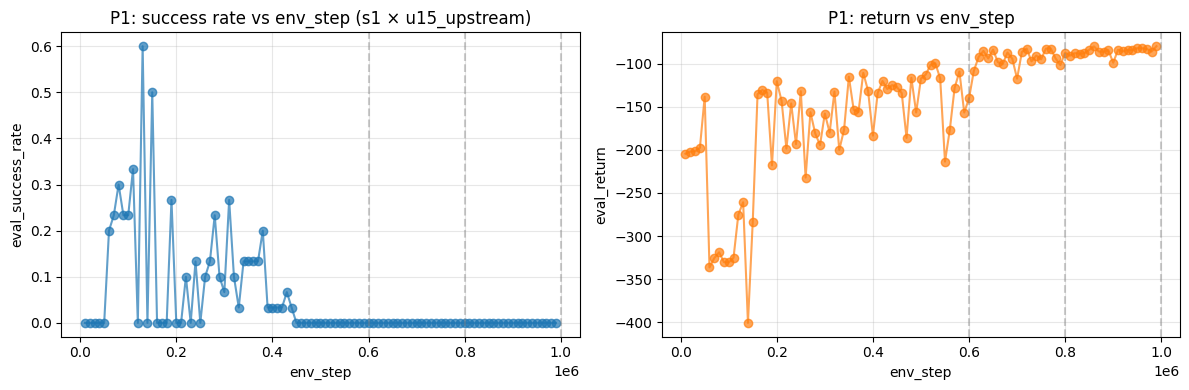

success @ 600k = 0.0
success @ 800k = 0.0
success @ 1M   = None


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 与 cell 8 的 STAGE_DIR 对齐：读 _v2_flowfix 这一份
run_dir = Path('experiments/online_thesis_v1/preflight/p1_budget_calibration_v2_flowfix'
               '/efficiency_v2/sac_vanilla/s1_k4/seed_46')
eval_log = run_dir / 'results' / 'eval_log.csv'
if not eval_log.exists():
    eval_log = run_dir / 'eval_log.csv'  # legacy flat layout

df = pd.read_csv(eval_log)
print(df[['env_step', 'eval_success_rate', 'eval_return']].tail(20))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df['env_step'], df['eval_success_rate'], marker='o', alpha=0.7)
for thr in [600_000, 800_000, 1_000_000]:
    ax[0].axvline(thr, ls='--', color='gray', alpha=0.4)
ax[0].set_xlabel('env_step'); ax[0].set_ylabel('eval_success_rate')
ax[0].set_title('P1: success rate vs env_step (s1 × u15_upstream)')
ax[0].grid(alpha=0.3)

ax[1].plot(df['env_step'], df['eval_return'], marker='o', alpha=0.7, color='tab:orange')
for thr in [600_000, 800_000, 1_000_000]:
    ax[1].axvline(thr, ls='--', color='gray', alpha=0.4)
ax[1].set_xlabel('env_step'); ax[1].set_ylabel('eval_return')
ax[1].set_title('P1: return vs env_step')
ax[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

# 简单 plateau 检测（最后 100k 与 600k 时点 success rate 差异）
def at_step(target):
    sub = df[df['env_step'] >= target]
    return None if sub.empty else sub.iloc[0]['eval_success_rate']

s_600k = at_step(600_000); s_800k = at_step(800_000); s_1M = at_step(1_000_000)
print(f'success @ 600k = {s_600k}')
print(f'success @ 800k = {s_800k}')
print(f'success @ 1M   = {s_1M}')


## 4. P2 — AsymCritic 纯 online smoke

**Setup**：

| 项 | 值 |
|---|---|
| sensor | `s0_k4` |
| difficulty | `single_u15_upstream_tgt15` |
| seed | `46` |
| total_steps | `50_000`（只看是否能跑通，不看性能） |
| flag | `--use-asymmetric-critic` + `--use-layernorm` + `--updates-per-step 4` |

**判据**：训练能跑完 50k 步、不报错、`final_eval.json` 写出 → P2 ✅。

**save_dir 加 `_v2_flowfix` 后缀**：旧路径用了 U=1.0 wake，本次复跑要在 production 设定（U=1.5）下复确认 AsymCritic 纯 online 路径仍然 smoke pass。`train_sac` 默认会**覆盖** save_dir 而非 resume（除非显式传 `--resume`），所以理论上不换路径也能重跑，但换路径更干净，避免污染历史记录。


In [ ]:
import os

from scripts.benchmark_catalog import resolve_benchmark_protocol
from scripts.notebook_utils import run_streaming

BENCHMARK_KEY = 'single_u15_upstream_tgt15'
proto = resolve_benchmark_protocol(BENCHMARK_KEY)

# _v2_flowfix：与 P1 同步策略
SAVE_DIR       = ('experiments/online_thesis_v1/preflight/p2_asym_online_smoke_v2_flowfix'
                  '/efficiency_v2/sac_asym_lnutd/s0_k4/seed_46')
CHECKPOINT_DIR = ('checkpoints/online_thesis_v1/preflight/p2_asym_online_smoke_v2_flowfix'
                  '/efficiency_v2/sac_asym_lnutd/s0_k4/seed_46')

# 先生成 manifest（如已存在则跳过）— 短命令，行流读也无所谓
run_streaming([
    'python3', '-m', 'scripts.generate_standard_benchmarks',
    '--benchmarks', BENCHMARK_KEY,
    '--episodes', '30',
])

# run_protocol_stage_common.sh 没有暴露 --use-asymmetric-critic / --use-layernorm，
# 直接拼 train_sac CLI 来确保 flag 完整传递
print(f'[P2] BENCHMARK_KEY = {BENCHMARK_KEY}')
print(f'[P2] FLOW_PATH     = {proto["flow_path"]}')
print(f'[P2] SAVE_DIR      = {SAVE_DIR}')
print('[P2] launching s0 × u15_upstream × seed=46 × 50k steps (AsymCritic+LN+UTD4) ...', flush=True)
run_streaming([
    'python3', '-m', 'scripts.train_sac',
    '--flow', proto['flow_path'],
    '--task-geometry', proto['task_geometry'],
    '--target-speed', proto['target_speed'],
    '--objective', 'efficiency_v2',
    '--probe-layout', 's0',
    '--history-length', '4',
    '--total-steps', '50000',
    '--random-steps', '5000',
    '--update-after', '5000',
    '--batch-size', '256',
    '--hidden-dim', '256',
    '--num-envs', '12',                          # P0b 决策（plan §10.2）
    '--eval-every', '10000',
    '--eval-episodes', '15',
    '--checkpoint-every', '50000',
    '--eval-manifest', f'benchmarks/{BENCHMARK_KEY}.json',
    '--seed', '46',
    '--device', 'cuda',
    '--save-dir', SAVE_DIR,
    '--checkpoint-dir', CHECKPOINT_DIR,
    # P2 核心 flags
    '--use-asymmetric-critic',
    '--use-layernorm',
    '--updates-per-step', '4',
])
print('[P2] done')


[done] single_u15_upstream_tgt15 -> benchmarks/single_u15_upstream_tgt15.json
[P2] BENCHMARK_KEY = single_u15_upstream_tgt15
[P2] FLOW_PATH     = wake_data/wake_v8_U1p50_Re250_D12p00_dx0p60_Ti5pct_1200f_roi.npy
[P2] SAVE_DIR      = experiments/online_thesis_v1/preflight/p2_asym_online_smoke_v2_flowfix/efficiency_v2/sac_asym_lnutd/s0_k4/seed_46
[P2] launching s0 × u15_upstream × seed=46 × 50k steps (AsymCritic+LN+UTD4) ...
[train] episode=5 step=972 return=-116.57 success=False time=40.2s geometry=upstream history=4
[train] episode=10 step=1512 return=-90.81 success=False time=21.8s geometry=upstream history=4
[train] episode=15 step=2304 return=-98.82 success=False time=25.2s geometry=upstream history=4
[train] episode=20 step=2952 return=-100.65 success=False time=26.1s geometry=upstream history=4
[train] episode=25 step=3648 return=-291.92 success=False time=91.4s geometry=upstream history=4
[train] episode=30 step=3912 return=-463.94 success=False time=162.6s geometry=upstream histo

## 5. P2 验证 — 跑通即过


In [ ]:
import json
from pathlib import Path

# 与 cell 12 的 SAVE_DIR 对齐
p2_run = Path('experiments/online_thesis_v1/preflight/p2_asym_online_smoke_v2_flowfix'
              '/efficiency_v2/sac_asym_lnutd/s0_k4/seed_46')

final_eval = p2_run / 'results' / 'final_eval.json'
if not final_eval.exists():
    final_eval = p2_run / 'final_eval.json'

assert final_eval.exists(), f'P2 FAILED: {final_eval} missing'
print(f'[P2] ✅ pass: final_eval.json written at {final_eval}')
print(json.loads(final_eval.read_text()))


[P2] ✅ pass: final_eval.json written at experiments/online_thesis_v1/preflight/p2_asym_online_smoke_v2_flowfix/efficiency_v2/sac_asym_lnutd/s0_k4/seed_46/results/final_eval.json
{'num_eval_episodes': 30.0, 'eval_return': -178.0138120134273, 'eval_return_std': 86.26997575859737, 'eval_cost': 14.417489139381217, 'eval_cost_std': 8.371513685023373, 'eval_safety_cost': 14.417489139381217, 'eval_safety_cost_std': 8.371513685023373, 'eval_success_rate': 0.0, 'eval_time_s': 58.66000000000003, 'eval_time_s_std': 24.99036614377564, 'eval_time_s_success': nan, 'eval_energy': 29058.302754148714, 'eval_energy_std': 10440.982357412031, 'eval_energy_success': nan, 'eval_path_length_m': 60.70504817389883, 'eval_path_length_m_std': 38.49162331502357, 'eval_path_length_success': nan, 'eval_progress_ratio': -0.6079455623421158, 'eval_progress_ratio_std': 0.6712689299052033, 'eval_path_efficiency': -0.47190016255877604, 'eval_path_efficiency_std': 0.2855437570236063, 'eval_termination_counts': {'out_of_b

## 6. 决策记录 — 落字到 thesis plan §10

跑完 P1 + P2 后，把结论填到 [`docs/online_rl_thesis_plan.md`](../docs/online_rl_thesis_plan.md) §10：

```
- u15_upstream 训练预算：______ steps
- AsymCritic online smoke：[ ] pass / [ ] 修复后 pass
- L4 wallclock 单 run 实测：______ h / 600k steps
```

只有 P1 + P2 都 ✅ 后，才能进 Sprint 1（§2 sensor envelope）。
